# Einführung in Jupyter Notebook

### Dietmar Hareter und Fabian Pribahsnik
### 08.04.2026

Ein Jupyter-Notebook besteht aus sogenannten Markdown-Zellen (wie diese hier) und ausführbaren Code-Zellen (nachfolgende Zelle)

In [1]:
suppressPackageStartupMessages({
  library(tidyverse)
  library(htmlwidgets)
  library(plotly)
})

Text

In einem Jupyter-Markdown-Feld sind ähnliche Formatierungsmöglichkeiten wie in einem R-Markdown vorhanden:

# Überschrift 1 (mit einer Raute)
## Überschrift 2 (mit zwei Rauten)
### Überschrift 3 (mit drei Rauten)

*kursiv* (mit einem Stern am Beginn und am Ende)  
**fett** (mit zwei Sternen am Beginn und am Ende) 

Listen:
- Punkt 1
- Punkt 2
- Punkt 3

Nummerierte Listen
1. erster Punkt
2. zweiter Punkt
3. dritter Punkt

# Einleitung

Das Einlesen von Daten erfolgt durch die Angabe von Pfaden relativ zum aktuellen Arbeitsverzeichnis (working directory). 

In [2]:
df <- readr::read_csv("data/demo_data.csv", show_col_types = FALSE)
df

group,value
<chr>,<dbl>
A,5.1
A,4.9
A,5.3
A,5.0
B,6.2
B,6.5
B,6.1
B,6.4


Im Folgenden wird allerdings der Datensatz *iris* verwendet, der standardmäßig in R vorhanden ist.

In [3]:
df <- iris
head(df)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
6,5.4,3.9,1.7,0.4,setosa


Standardmäßig können in Markdown-Zellen keine Variablen ausgewertet werden. Die Analysen müssen in Code-Zellen erfolgen.

In [4]:
# Größe des Iris-Datensatzes
nrow(iris) # Zeilen
ncol(iris) # Spalten

[1] 150

[1] 5

Ergebnisse oder Zwischenergebnisse der Analysen können jederzeit gespeichert werden.

In [5]:
readr::write_csv(df, "iris.csv")

Notebooks können sowohl statische Grafiken enthalten ...

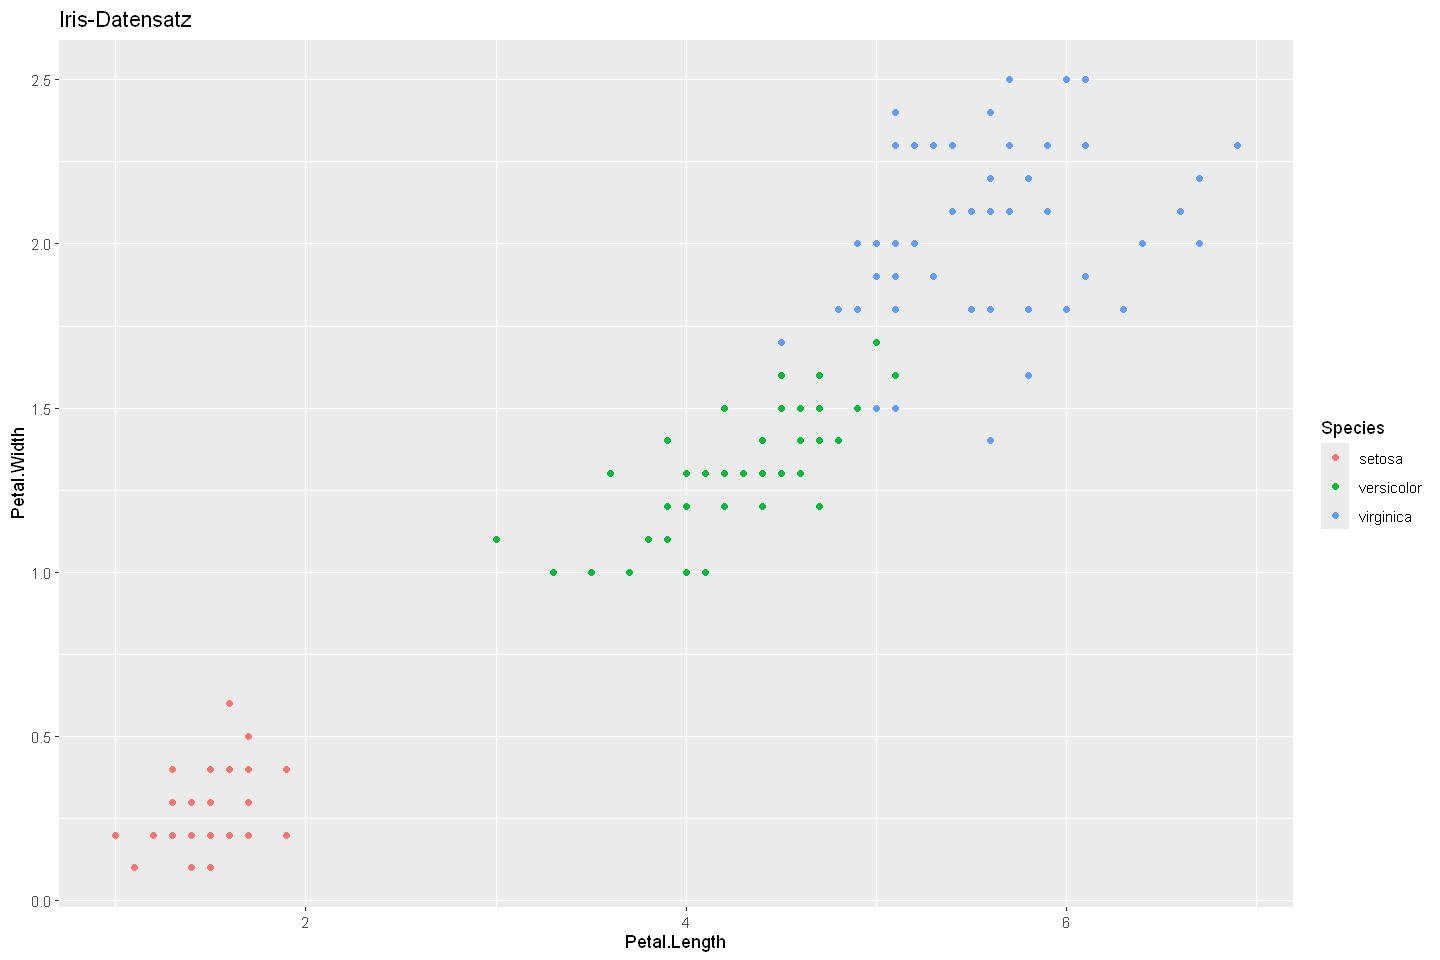

In [6]:
options(repr.plot.width = 12, repr.plot.height = 8) # Anpassung der Größe der im Folgenden erzeugten Plots

ggplot(iris, aes(Petal.Length, Petal.Width, color = Species)) +
  geom_point() +
  labs(
    title = "Iris-Datensatz",
    x = "Petal.Length",
    y = "Petal.Width"
  )

... als auch interaktive Grafiken.

In [7]:
Sys.setenv(RSTUDIO_PANDOC = "C:/Program Files/RStudio/resources/app/bin/quarto/bin/tools")
p <- plot_ly(
    data = iris,
    x = ~Petal.Length,
    y = ~Petal.Width,
    color = ~Species,
    type = "scatter",
    mode = "markers"
  ) %>%
    layout(
      title = "Iris-Datensatz",
      xaxis = list(title = "Petal.Length"),
      yaxis = list(title = "Petal.Width")
    )

saveWidget(p, "interaktive_grafik.html", selfcontained = TRUE)

IRdisplay::display_html('
<iframe
  src="interaktive_grafik.html"
  width="100%"
  height="500"
  style="border:none;">
</iframe>
')

Die Werte der einzelnen Variablen werden in Arbeitsspeicher gehalten.

Definition der Variable:

In [8]:
Variable <- 10
Variable

[1] 10

**Beginn der Analyse**



In [9]:
Ergebnis <- Variable * 2
Ergebnis

[1] 20

Veränderung der Variable

In [10]:
Variable <- 100
Variable

[1] 100

Wird die Analyse wieder am Beginn der Analyse gestartet, enthält *Variable* den aktuellen Wert und die Ergebnisse werden sich verändern.

## sessionInfo()

Für die Nachvollziehbarkeit der Ergebnisse ist es sinnvoll, die sogenannte *sessionInfo* auszugeben. 

In [11]:
sessionInfo()

R version 4.5.2 (2025-10-31 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 22631)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=German_Austria.utf8  LC_CTYPE=German_Austria.utf8   
[3] LC_MONETARY=German_Austria.utf8 LC_NUMERIC=C                   
[5] LC_TIME=German_Austria.utf8    

time zone: Europe/Vienna
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] plotly_4.11.0     htmlwidgets_1.6.4 lubridate_1.9.4   forcats_1.0.1    
 [5] stringr_1.6.0     dplyr_1.1.4       purrr_1.2.1       readr_2.1.6      
 [9] tidyr_1.3.2       tibble_3.3.1      ggplot2_4.0.1     tidyverse_2.0.0  

loaded via a namespace (and not attached):
 [1] generics_0.1.4     stringi_1.8.7      hms_1.1.4          digest_0.6.39     
 [5] magrittr_2.0.4     evaluate_1.0.5     grid_4.5.2         timechange_0.3.0  
 [9] RColorBrewer_1.1-3 pbdZMQ_0.3-14      fas